# 01 - Exploratory Data Analysis

**Model objective:** classify task duration into duration buckets, such as Quick, Standard, Extended, or Long-Range, using relevant raw Jira ticket fields.

#### 01-01 Dataset Shape Inspection

Let's identify the dataset shape to confirm the number of rows and columns available for analysis.



In [ ]:
import pandas as pd

ticket_df = pd.read_csv('../jira_ticket_dataset.csv')
pd.set_option('display.max_rows', None)

ticket_df.shape

C:\Users\Omar\AppData\Local\Temp\ipykernel_5164\2614111865.py:3: DtypeWarning: Columns (0: customfield_12310921, 1: issuetype.subtask) have mixed types. Specify dtype option on import or set low_memory=False.
  ticket_df = pd.read_csv('../jira_ticket_dataset.csv')


(1149323, 37)

**This tells us we have 1.4M rows and 37 columns.**


Next, review the available columns, non-null counts, and inferred data types.

In [ ]:
ticket_df.head().info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           5 non-null      float64
 1   key                          5 non-null      str    
 2   summary                      5 non-null      str    
 3   resolution.id                3 non-null      float64
 4   resolution.description       3 non-null      str    
 5   resolution.name              3 non-null      str    
 6   priority.id                  5 non-null      float64
 7   priority.name                5 non-null      str    
 8   labels                       5 non-null      str    
 9   assignee                     2 non-null      str    
 10  status.id                    5 non-null      float64
 11  status.description           5 non-null      str    
 12  status.name                  5 non-null      str    
 13  statusCategory.id            5 non-

#### 01-02 Dataset Feature Extraction

Based on the dataframe inspection, the most relevant raw features to keep for initial modeling are:

- **summary**: ticket title or short task description

- **description**: longer issue details

- **priority.name**: priority category

- **labels**: assigned Jira labels

- **issuetype.description**: description of the issue type

- **issuetype.name**: issue type label

- **issuetype.subtask**: whether the issue is a subtask

- **resolutiondate**: timestamp used to derive duration

- **created**: timestamp used to derive duration

- **watches.watchCount**: number of watchers


Some raw features will later be transformed into engineered model inputs:


- **summary**: can be used for text length and keyword features

- **description**: can be used for text length and keyword features

- **labels**: can be used for label-count features

- **resolutiondate** and **created**: can be used to derive task duration




A crucial target-related feature is **duration_days**, derived from the difference between the resolution timestamp and the creation timestamp.

```python

duration_days = resolutiondate - created

```


The planned duration buckets are:


- 0-3 days: Quick

- 4-7 days: Standard

- 8-14 days: Extended

- 15+ days: Long-range






In [ ]:
raw_feature_columns = [

    "summary",
    "description",
    "priority.name",
    "labels",
    "issuetype.description",
    "issuetype.name",
    "issuetype.subtask",
    "resolutiondate",
    "created",
    "watches.watchCount"

]

raw_feature_sample = ticket_df.loc[:, raw_feature_columns].sample(n=10,random_state=42)
print(raw_feature_sample)

#### 01-03 Dataset Shape Visualization

To better understand the shape of the data it can help to visualize it.

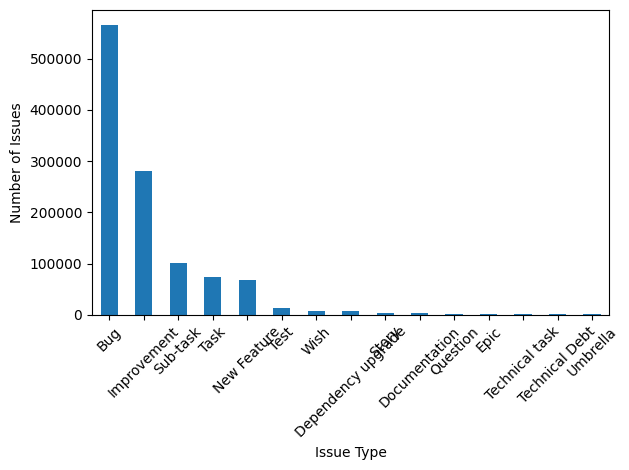

In [16]:
import matplotlib.pyplot as plt

ticket_df["issuetype.name"].value_counts().head(15).plot(kind="bar")
plt.xlabel("Issue Type")
plt.ylabel("Number of Issues")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()